# Train channel-invariant InstanSeg on CPDMI + TissueNet

This notebook deliberately follows InstanSeg's official `notebooks/training_minimal.ipynb` and `notebooks/load_datasets.ipynb` pattern and imports InstanSeg from the active Conda environment.

1. configure the InstanSeg raw-data and output directories;
2. construct an in-memory `Segmentation_Dataset`;
3. load CPDMI and TissueNet using the official loader functions;
4. inspect and optionally save the combined dataset; and
5. call `instanseg.scripts.train.instanseg_training(...)` directly.

The first baseline predicts nuclei and cells, uses ChannelNet, resamples to **0.325 µm/pixel**, and uses the official **minimal** augmentation preset. No InstanSeg source changes are required.

> TissueNet has restricted/non-commercial terms. Confirm that the intended use is compatible with its license before training or distributing a derived model.


## 1. Paths and imports

Set `INSTANSEG_TRAINING_ROOT` to storage with room for roughly 150+ GB of raw downloads, the serialized combined dataset, and model outputs. The directory layout below matches the official loader notebook.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import torch

training_root_value = os.environ.get("INSTANSEG_TRAINING_ROOT", "/data1/lowes/ratnayn/Data/instanseg")
if not training_root_value:
    raise RuntimeError(
        "Set INSTANSEG_TRAINING_ROOT to a large-data location before continuing, "
        "for example: export INSTANSEG_TRAINING_ROOT=/data1/lowes/ratnayn/Data/instanseg"
    )

TRAINING_ROOT = Path(training_root_value).expanduser().resolve()
RAW_DATASETS = TRAINING_ROOT / "Raw_Datasets"
DATASET_PATH = TRAINING_ROOT / "datasets"
MODEL_PATH = TRAINING_ROOT / "models"
INCLUDE_CPDMI_CODEX = False  # Preserve CODEX as a cross-platform holdout by default.
for path in (RAW_DATASETS, DATASET_PATH, MODEL_PATH):
    path.mkdir(parents=True, exist_ok=True)

os.environ["INSTANSEG_RAW_DATASETS"] = str(RAW_DATASETS)
os.environ["INSTANSEG_DATASET_PATH"] = str(DATASET_PATH)
os.environ["INSTANSEG_OUTPUT_PATH"] = str(MODEL_PATH)

print(f"Raw datasets:     {RAW_DATASETS}")
print(f"Dataset files:    {DATASET_PATH}")
print(f"Model outputs:    {MODEL_PATH}")


InstanSeg source: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/Reference/instanseg-main
Raw datasets:     /data1/lowes/ratnayn/Data/instanseg/Raw_Datasets
Dataset files:    /data1/lowes/ratnayn/Data/instanseg/datasets
Model outputs:    /data1/lowes/ratnayn/Data/instanseg/models


## 2. Environment and H200 check

The upstream training loop does not wrap the full forward/backward pass in AMP, so an H200 does not automatically train in BF16. We leave that code unchanged for this baseline. The initial full-run batch size below is 8 instead of the paper/tutorial default of 3. After the baseline works, try 12 and then 16 while watching peak GPU and host memory.

Mixed-channel batches are padded to the largest channel count in that batch, so memory usage can vary substantially between batches.


In [2]:
import instanseg

instanseg_import_path = Path(instanseg.__file__).resolve()
print(f"InstanSeg imported from: {instanseg_import_path}")
if "Reference/instanseg-main" in instanseg_import_path.as_posix():
    raise RuntimeError("Restart the kernel: it still has the old editable Reference-folder InstanSeg import cached.")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    device = torch.cuda.current_device()
    properties = torch.cuda.get_device_properties(device)
    print(f"GPU: {properties.name}")
    print(f"GPU memory: {properties.total_memory / 1024**3:.1f} GiB")
    print(f"CUDA runtime: {torch.version.cuda}")
else:
    raise RuntimeError("CUDA is not available in this notebook kernel.")


InstanSeg imported from: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/Reference/instanseg-main/instanseg/__init__.py
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA H200 NVL
GPU memory: 139.8 GiB
CUDA runtime: 12.8


## 3. Raw-data prerequisites

Follow the official `Reference/instanseg-main/notebooks/load_datasets.ipynb` download instructions before running the loader cell. Expected locations are:

```text
Raw_Datasets/Cell_Segmentation/CPDMI_2023/
├── Annotation Panel Table.xlsx
├── Vectra/
├── Zeiss/
└── CODEX/

Raw_Datasets/Cell_Segmentation/TissueNet/
└── <unzipped TissueNet v1.1 contents>
```

CPDMI is downloaded through Synapse. TissueNet v1.1 must be obtained manually from DeepCell and unzipped. By default this notebook loads CPDMI Vectra and Zeiss but leaves CODEX out as a cross-platform holdout, matching the experimental intent described in the paper. Set `INCLUDE_CPDMI_CODEX=True` only if CODEX should become training data. In this source snapshot, `load_CPDMI_CODEX()` appends its records to `Train`, so loading it would prevent a clean CODEX holdout.

> The official Zeiss loader can delete a larger redundant image when it finds multiple candidate image files in one sample directory. Keep an archival copy of the raw download if that matters for your data management.


In [3]:
required_paths = [
    RAW_DATASETS / "Cell_Segmentation" / "CPDMI_2023" / "Annotation Panel Table.xlsx",
    RAW_DATASETS / "Cell_Segmentation" / "CPDMI_2023" / "Vectra",
    RAW_DATASETS / "Cell_Segmentation" / "CPDMI_2023" / "Zeiss",
    RAW_DATASETS / "Cell_Segmentation" / "TissueNet" / "tissuenet_v1.1" / "tissuenet_v1.1_train.npz",
    RAW_DATASETS / "Cell_Segmentation" / "TissueNet" / "tissuenet_v1.1" / "tissuenet_v1.1_val.npz",
    RAW_DATASETS / "Cell_Segmentation" / "TissueNet" / "tissuenet_v1.1" / "tissuenet_v1.1_test.npz",
]
if INCLUDE_CPDMI_CODEX:
    required_paths.append(RAW_DATASETS / "Cell_Segmentation" / "CPDMI_2023" / "CODEX")
missing = [path for path in required_paths if not path.exists()]
if missing:
    print("Missing raw-data directories:")
    for path in missing:
        print(f"  - {path}")
    print("Complete the official loader-notebook download steps before loading.")
else:
    print("All expected raw-data directories are present.")


All expected raw-data directories are present.


## 4. Load CPDMI and TissueNet

This is the same in-memory accumulation pattern used by the official notebooks. Loading and serializing the complete collection can require substantial CPU RAM.


In [4]:
Segmentation_Dataset = {"Train": [], "Validation": [], "Test": []}

from instanseg.utils.data_download import (
    load_CPDMI_CODEX,
    load_CPDMI_Vectra,
    load_CPDMI_Zeiss,
    load_tissuenet,
)

Segmentation_Dataset = load_CPDMI_Vectra(Segmentation_Dataset)
Segmentation_Dataset = load_CPDMI_Zeiss(Segmentation_Dataset)
if INCLUDE_CPDMI_CODEX:
    Segmentation_Dataset = load_CPDMI_CODEX(Segmentation_Dataset)
Segmentation_Dataset = load_tissuenet(Segmentation_Dataset, no_zip=True)

# TissueNet v1.1 stores column-header rows inside each NPZ meta array, but not
# inside X or y. The upstream loader indexes meta without removing those rows,
# shifting every sample's physical pixel size (and producing the literal string
# 'pixel_size' for the first sample). Re-align metadata with the items created by
# the official loader while leaving its image/mask conversion unchanged.
tissuenet_root = RAW_DATASETS / "Cell_Segmentation" / "TissueNet" / "tissuenet_v1.1"
tissuenet_splits = {"Train": "train", "Validation": "val", "Test": "test"}
tissuenet_native_validation_count = 1_198
for split, npz_split in tissuenet_splits.items():
    with np.load(tissuenet_root / f"tissuenet_v1.1_{npz_split}.npz", allow_pickle=True) as data:
        metadata_rows = [
            row for row in data["meta"]
            if not (len(row) > 2 and str(row[2]).strip().lower() == "pixel_size")
        ]
    if split == "Validation":
        assert len(metadata_rows) == 3_118
        assert np.array_equal(
            np.asarray(metadata_rows[:tissuenet_native_validation_count]),
            np.asarray(metadata_rows[tissuenet_native_validation_count:2 * tissuenet_native_validation_count]),
        ), "Unexpected TissueNet validation-copy layout; re-audit its pixel sizes."
    tissuenet_items = [
        item for item in Segmentation_Dataset[split]
        if item.get("parent_dataset") == "TissueNet"
    ]
    assert len(tissuenet_items) == len(metadata_rows), (
        f"TissueNet {split} item/metadata mismatch: "
        f"{len(tissuenet_items)} items versus {len(metadata_rows)} metadata rows"
    )
    for source_index, (item, metadata) in enumerate(zip(tissuenet_items, metadata_rows)):
        item["pixel_size"] = float(metadata[2])
        item["tissuenet_source_index"] = source_index
        item["source_experiment"] = str(metadata[1])
        item["tissue_type"] = str(metadata[5])

# TissueNet v1.1 source indices 0-3 have a reproducible image/annotation
# mismatch in every split. In train, nuclear image channels 0,1,2,3 match
# nuclear masks 1,2,3,0, respectively; validation/test versions are also
# visibly unaligned. This is present in the raw NPZ, not introduced by the
# InstanSeg conversion. Exclude these 12 records rather than train on them.
bad_tissuenet_source_indices = {0, 1, 2, 3}

# The validation NPZ contains 1,198 native-resolution tiles followed by two
# deliberately resized copies. Rows 1,198:2,396 repeat the first block's
# metadata exactly, including the original pixel size, and rows 2,396:3,118
# form a second resized tier whose pixel sizes are also not adjusted. Retain
# only the native block so requested_pixel_size performs a physical, rather
# than metadata-confounded, rescaling. Train and test lack these extra copies.
for split in tissuenet_splits:
    before = len(Segmentation_Dataset[split])
    Segmentation_Dataset[split] = [
        item for item in Segmentation_Dataset[split]
        if not (
            item.get("parent_dataset") == "TissueNet"
            and (
                item.get("tissuenet_source_index") in bad_tissuenet_source_indices
                or (
                    split == "Validation"
                    and item.get("tissuenet_source_index") >= tissuenet_native_validation_count
                )
            )
        )
    ]
    print(f"Excluded {before - len(Segmentation_Dataset[split])} invalid/non-native TissueNet records from {split}.")

# Normalize metadata types used by InstanSeg's augmentation code. In particular,
# torch_rescale accepts physical pixel size only when it is a Python float.
selected_datasets = {"CPDMI_2023", "TissueNet"}
for items in Segmentation_Dataset.values():
    for item in items:
        if item.get("parent_dataset") not in selected_datasets:
            continue
        if "pixel_size" not in item:
            raise KeyError(f"Missing pixel_size metadata: {item.get('filename', item)}")
        item["pixel_size"] = float(item["pixel_size"])
        if "nuclei_channels" in item:
            item["nuclei_channels"] = [int(index) for index in item["nuclei_channels"]]

print({split: len(items) for split, items in Segmentation_Dataset.items()})


100%|██████████| 1324/1324 [00:21<00:00, 62.05it/s]


Excluded 4 invalid/non-native TissueNet records from Train.
Excluded 1924 invalid/non-native TissueNet records from Validation.
Excluded 4 invalid/non-native TissueNet records from Test.
{'Train': 2692, 'Validation': 1224, 'Test': 1320}


## 5. Audit the combined dataset

For `target_segmentation="NC"`, InstanSeg supports partially annotated records. When an item contains only nuclei or only cells, the official formatter fills the unavailable target with `-1`, which the loss treats as ignored. TissueNet contributes paired masks; CPDMI can contribute paired or single-compartment annotations. Every selected record must therefore have at least one of the two masks, not necessarily both.

The notebook supplements the official TissueNet loader records with the corrected physical pixel size, original TissueNet index, source experiment, and tissue type. It excludes source indices 0-3 from each split because direct image/label overlays show a reproducible source-level mismatch. It also retains only validation indices 0-1,197: TissueNet's remaining 1,920 validation records are resized copies whose metadata incorrectly retains the source pixel size. Platform and species are not present in TissueNet's per-image NPZ metadata and are not consumed by the minimal augmentation or model.


In [5]:
for split, items in Segmentation_Dataset.items():
    by_dataset = Counter(item.get("parent_dataset", "<missing>") for item in items)
    missing_nuclei = sum("nucleus_masks" not in item for item in items)
    missing_cells = sum("cell_masks" not in item for item in items)
    paired = sum("nucleus_masks" in item and "cell_masks" in item for item in items)
    pixel_sizes = sorted({item.get("pixel_size") for item in items if item.get("pixel_size") is not None})
    print(f"{split}: {len(items):,} items")
    print(f"  parent datasets: {dict(by_dataset)}")
    print(f"  missing nucleus masks: {missing_nuclei:,}")
    print(f"  missing cell masks:    {missing_cells:,}")
    print(f"  paired N+C masks:      {paired:,}")
    print(f"  native pixel sizes:    {pixel_sizes}")

for split in ("Train", "Validation"):
    selected = [
        item for item in Segmentation_Dataset[split]
        if item.get("parent_dataset") in {"CPDMI_2023", "TissueNet"}
    ]
    assert selected, f"No selected items found in {split}."
    assert all("nucleus_masks" in item or "cell_masks" in item for item in selected), (
        f"Some selected {split} items contain neither nuclei nor cell masks."
    )


Train: 2,692 items
  parent datasets: {'CPDMI_2023': 116, 'TissueNet': 2576}
  missing nucleus masks: 77
  missing cell masks:    3
  paired N+C masks:      2,612
  native pixel sizes:    [0.25, 0.325, 0.365, 0.38, 0.5, 1.0]
Validation: 1,224 items
  parent datasets: {'CPDMI_2023': 30, 'TissueNet': 1194}
  missing nucleus masks: 23
  missing cell masks:    0
  paired N+C masks:      1,201
  native pixel sizes:    [0.25, 0.325, 0.365, 0.38, 0.5, 1.0]
Test: 1,320 items
  parent datasets: {'TissueNet': 1320}
  missing nucleus masks: 0
  missing cell masks:    0
  paired N+C masks:      1,320
  native pixel sizes:    [0.365, 0.38, 0.5, 1.0]


### Full training-data preflight

This reads every CPDMI and TissueNet image used by the trainer, along with its available masks. It validates channel-axis interpretation, spatial alignment, required metadata, and nuclear-channel indices. Run it before saving the combined dataset. On network storage it may take several minutes.


In [6]:
from collections import defaultdict

from instanseg.utils.data_loader import get_image
from instanseg.utils.utils import _move_channel_axis

PREFLIGHT_SPLITS = ("Train", "Validation")
issues = []
preflight_summary = defaultdict(lambda: {
    "items": 0, "channels": [], "pixel_sizes": set(),
    "paired": 0, "nuclei_only": 0, "cells_only": 0,
})

for split in PREFLIGHT_SPLITS:
    for index, item in enumerate(Segmentation_Dataset[split]):
        dataset_name = item.get("parent_dataset")
        if dataset_name not in selected_datasets:
            continue

        context = f"{split}[{index}]/{dataset_name}"
        summary = preflight_summary[(split, dataset_name)]
        summary["items"] += 1

        if item.get("image_modality") != "Fluorescence":
            issues.append(f"{context}: image_modality is {item.get('image_modality')!r}")

        pixel_size = item.get("pixel_size")
        if not isinstance(pixel_size, float) or not np.isfinite(pixel_size) or pixel_size <= 0:
            issues.append(f"{context}: invalid pixel_size {pixel_size!r} ({type(pixel_size).__name__})")
        else:
            summary["pixel_sizes"].add(pixel_size)

        has_nuclei = "nucleus_masks" in item
        has_cells = "cell_masks" in item
        if has_nuclei and has_cells:
            summary["paired"] += 1
        elif has_nuclei:
            summary["nuclei_only"] += 1
        elif has_cells:
            summary["cells_only"] += 1
        else:
            issues.append(f"{context}: neither nucleus_masks nor cell_masks is present")

        try:
            image = np.asarray(get_image(item["image"]))
            image_chw = np.asarray(_move_channel_axis(image))
        except Exception as error:
            issues.append(f"{context}: image could not be loaded: {error}")
            continue

        if image_chw.ndim != 3:
            issues.append(f"{context}: expected a 3D image, found {image.shape}")
            continue
        channels, height, width = image_chw.shape
        summary["channels"].append(channels)
        if channels < 2:
            issues.append(f"{context}: expected at least 2 channels, found {channels}")
        if dataset_name == "TissueNet" and channels != 2:
            issues.append(f"{context}: TissueNet should have exactly 2 channels, found {channels}")
        if not np.issubdtype(image_chw.dtype, np.number) or not np.isfinite(image_chw).all():
            issues.append(f"{context}: image contains a non-numeric or non-finite value")

        nuclei_channels = item.get("nuclei_channels")
        if not nuclei_channels:
            issues.append(f"{context}: nuclei_channels metadata is missing or empty")
        elif any(not isinstance(channel, int) or channel < 0 or channel >= channels for channel in nuclei_channels):
            issues.append(f"{context}: invalid nuclei_channels {nuclei_channels} for {channels} channels")
        if dataset_name == "TissueNet" and nuclei_channels != [0]:
            issues.append(f"{context}: TissueNet nuclear channel should be [0], found {nuclei_channels}")

        channel_names = item.get("channel_names")
        if channel_names is not None and len(channel_names) != channels:
            issues.append(f"{context}: {len(channel_names)} channel names for {channels} image channels")

        for mask_key in ("nucleus_masks", "cell_masks"):
            if mask_key not in item:
                continue
            try:
                mask = np.asarray(get_image(item[mask_key])).squeeze()
            except Exception as error:
                issues.append(f"{context}: {mask_key} could not be loaded: {error}")
                continue
            if mask.ndim != 2 or mask.shape != (height, width):
                issues.append(
                    f"{context}: {mask_key} shape {mask.shape} does not match image {(height, width)}"
                )
            if not np.issubdtype(mask.dtype, np.integer):
                issues.append(f"{context}: {mask_key} dtype is not integer: {mask.dtype}")
            elif mask.size and mask.min() < 0:
                issues.append(f"{context}: {mask_key} contains negative raw labels")

for (split, dataset_name), summary in sorted(preflight_summary.items()):
    channels = summary["channels"]
    channel_range = (min(channels), max(channels)) if channels else None
    print(
        f"{split}/{dataset_name}: items={summary['items']:,}, "
        f"channels={channel_range}, pixel_sizes={sorted(summary['pixel_sizes'])}, "
        f"paired={summary['paired']:,}, nuclei_only={summary['nuclei_only']:,}, "
        f"cells_only={summary['cells_only']:,}"
    )

if issues:
    print(f"Preflight found {len(issues):,} issue(s). First 50:")
    for issue in issues[:50]:
        print(f"  - {issue}")
    raise AssertionError("Dataset preflight failed; do not start training.")

print("Dataset preflight passed. CPDMI and TissueNet are ready for training.")


Train/CPDMI_2023: items=116, channels=(5, 8), pixel_sizes=[0.25, 0.325, 0.5], paired=36, nuclei_only=3, cells_only=77
Train/TissueNet: items=2,576, channels=(2, 2), pixel_sizes=[0.365, 0.38, 0.5, 1.0], paired=2,576, nuclei_only=0, cells_only=0
Validation/CPDMI_2023: items=30, channels=(5, 8), pixel_sizes=[0.25, 0.325, 0.5], paired=7, nuclei_only=0, cells_only=23
Validation/TissueNet: items=1,194, channels=(2, 2), pixel_sizes=[0.365, 0.38, 0.5, 1.0], paired=1,194, nuclei_only=0, cells_only=0
Dataset preflight passed. CPDMI and TissueNet are ready for training.


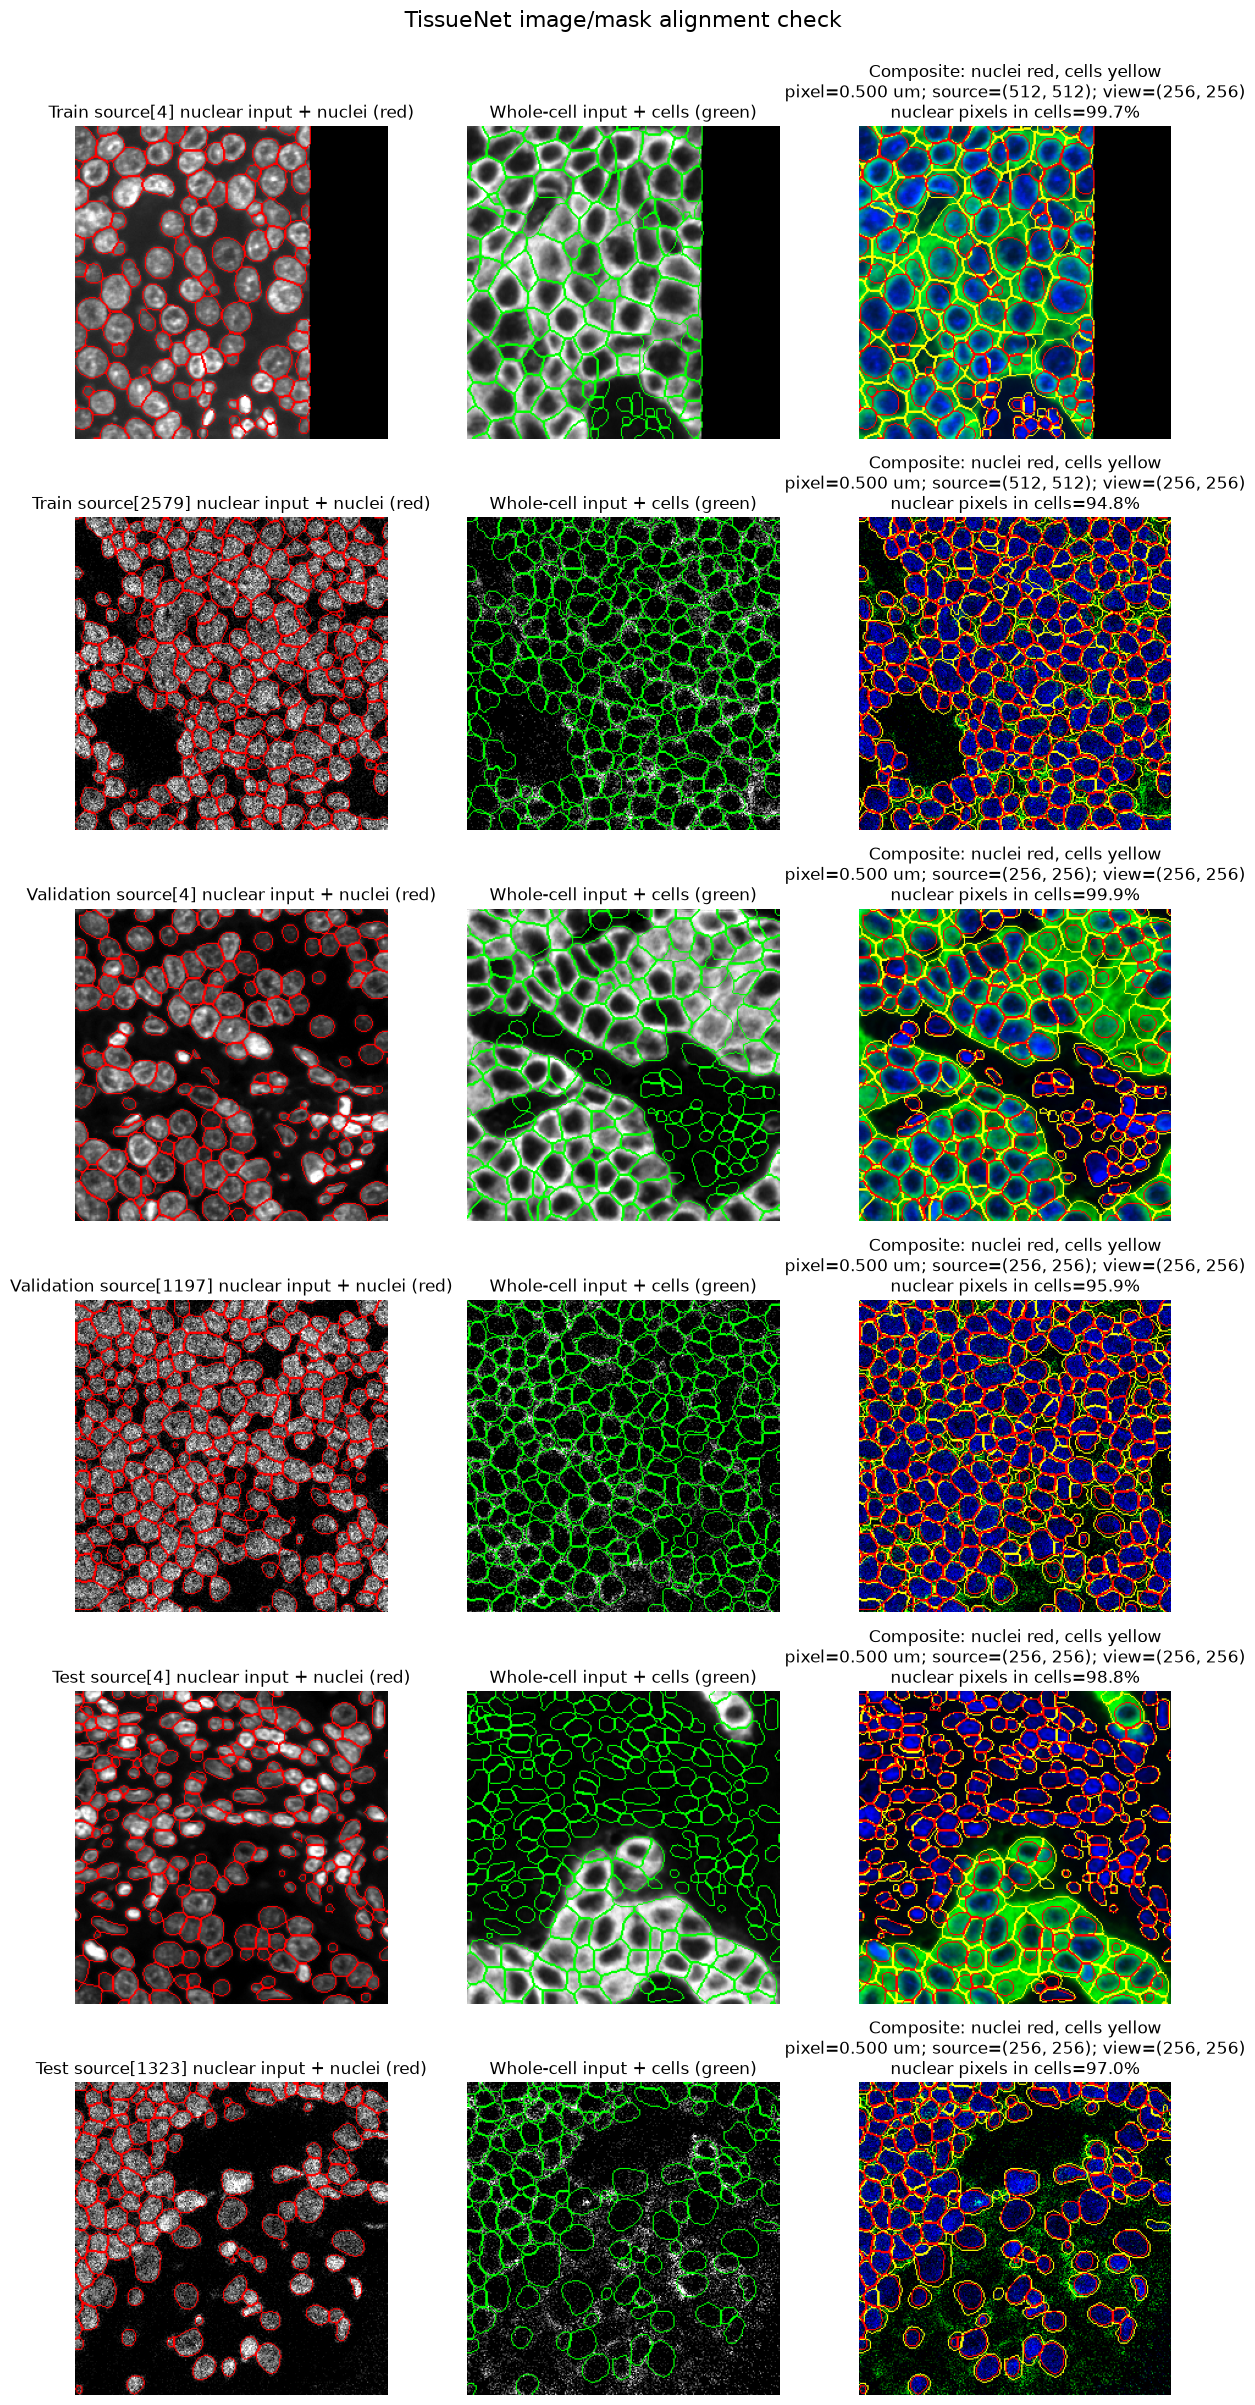

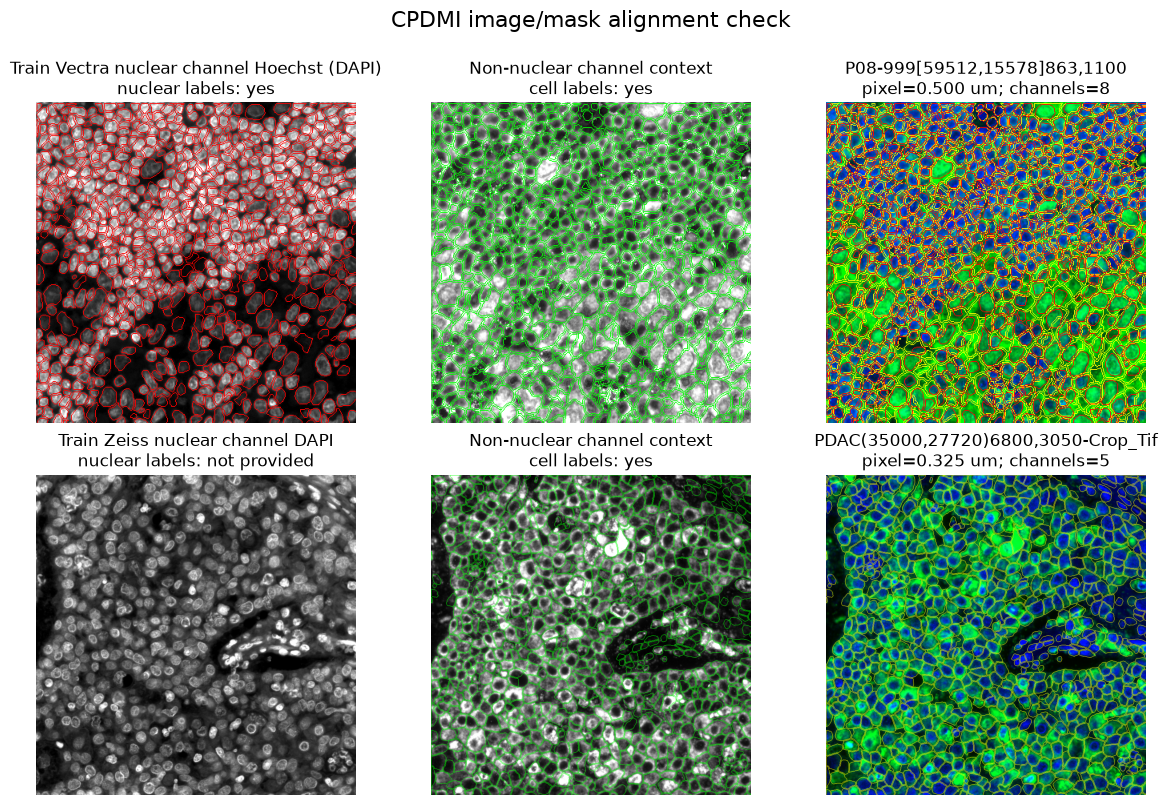

In [7]:
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

from instanseg.utils.data_loader import get_image
from instanseg.utils.utils import _move_channel_axis


def normalize_for_display(channel):
    channel = np.asarray(channel, dtype=np.float32)
    low, high = np.percentile(channel, (1, 99.5))
    if high <= low:
        return np.zeros_like(channel)
    return np.clip((channel - low) / (high - low), 0, 1)


def boundary_overlay(base, labels, color):
    rgb = np.repeat(base[..., None], 3, axis=-1)
    rgb[find_boundaries(labels, mode="inner")] = color
    return rgb


# Do not use display_colourized() for this check: it blends the two input
# channels and can make otherwise aligned masks look mismatched. TissueNet
# defines input channel 0 as nuclear, input channel 1 as whole-cell, label
# channel 0 as cell masks, and label channel 1 as nuclear masks.
tissuenet_examples = []
for split in ("Train", "Validation", "Test"):
    candidates = [
        item for item in Segmentation_Dataset[split]
        if item.get("parent_dataset") == "TissueNet"
        and "nucleus_masks" in item and "cell_masks" in item
    ]
    for local_index in np.linspace(0, len(candidates) - 1, 2, dtype=int):
        tissuenet_examples.append((split, int(local_index), candidates[local_index]))

fig, axes = plt.subplots(len(tissuenet_examples), 3, figsize=(12, 4 * len(tissuenet_examples)))
for row, (split, local_index, item) in enumerate(tissuenet_examples):
    image_chw = np.asarray(_move_channel_axis(get_image(item["image"])))
    nuclei = np.asarray(get_image(item["nucleus_masks"])).squeeze()
    cells = np.asarray(get_image(item["cell_masks"])).squeeze()
    native_shape = image_chw.shape[1:]
    # Train records are 512x512, whereas validation/test are 256x256. Show a
    # common 256x256 center view so equal-size plot panels imply equal pixel
    # scale instead of visually magnifying validation/test by two-fold.
    view_height = min(256, native_shape[0])
    view_width = min(256, native_shape[1])
    top = (native_shape[0] - view_height) // 2
    left = (native_shape[1] - view_width) // 2
    image_chw = image_chw[:, top:top + view_height, left:left + view_width]
    nuclei = nuclei[top:top + view_height, left:left + view_width]
    cells = cells[top:top + view_height, left:left + view_width]
    nuclear_channel = normalize_for_display(image_chw[0])
    whole_cell_channel = normalize_for_display(image_chw[1])

    nuclei_in_cells = ((nuclei > 0) & (cells > 0)).sum() / max((nuclei > 0).sum(), 1)
    composite = np.stack(
        [np.zeros_like(nuclear_channel), whole_cell_channel, nuclear_channel], axis=-1
    )
    composite[find_boundaries(cells, mode="inner")] = (1, 1, 0)
    composite[find_boundaries(nuclei, mode="inner")] = (1, 0, 0)

    axes[row, 0].imshow(boundary_overlay(nuclear_channel, nuclei, (1, 0, 0)))
    source_index = item["tissuenet_source_index"]
    axes[row, 0].set_title(
        f"{split} source[{source_index}] nuclear input + nuclei (red)"
    )
    axes[row, 1].imshow(boundary_overlay(whole_cell_channel, cells, (0, 1, 0)))
    axes[row, 1].set_title("Whole-cell input + cells (green)")
    axes[row, 2].imshow(composite)
    axes[row, 2].set_title(
        f"Composite: nuclei red, cells yellow\n"
        f"pixel={item['pixel_size']:.3f} um; source={native_shape}; view={image_chw.shape[1:]}\n"
        f"nuclear pixels in cells={nuclei_in_cells:.1%}"
    )
    for axis in axes[row]:
        axis.axis("off")

fig.suptitle("TissueNet image/mask alignment check", fontsize=16, y=1.0)
fig.tight_layout()
plt.show()


# CPDMI uses platform-specific channel panels. Show the declared nuclear
# channel separately and use a normalized max projection of all remaining
# channels as whole-cell context. Zeiss records generally have cell labels
# only, while the selected Vectra example preferentially has paired labels.
cpdmi_examples = []
for platform in ("Vectra", "Zeiss"):
    candidates = [
        (split, item)
        for split in ("Train", "Validation")
        for item in Segmentation_Dataset[split]
        if item.get("parent_dataset") == "CPDMI_2023"
        and item.get("platform") == platform
    ]
    selected = next(
        ((split, item) for split, item in candidates
         if "nucleus_masks" in item and "cell_masks" in item),
        candidates[0],
    )
    cpdmi_examples.append(selected)

fig, axes = plt.subplots(len(cpdmi_examples), 3, figsize=(12, 4 * len(cpdmi_examples)))
for row, (split, item) in enumerate(cpdmi_examples):
    image_chw = np.asarray(_move_channel_axis(get_image(item["image"])))
    nuclear_index = item["nuclei_channels"][0]
    nuclear_channel = normalize_for_display(image_chw[nuclear_index])
    context_indices = [i for i in range(image_chw.shape[0]) if i != nuclear_index]
    whole_cell_context = np.max(
        np.stack([normalize_for_display(image_chw[i]) for i in context_indices]), axis=0
    )
    nuclei = (
        np.asarray(get_image(item["nucleus_masks"])).squeeze()
        if "nucleus_masks" in item else np.zeros(image_chw.shape[1:], dtype=np.int32)
    )
    cells = (
        np.asarray(get_image(item["cell_masks"])).squeeze()
        if "cell_masks" in item else np.zeros(image_chw.shape[1:], dtype=np.int32)
    )

    composite = np.stack(
        [np.zeros_like(nuclear_channel), whole_cell_context, nuclear_channel], axis=-1
    )
    if cells.max() > 0:
        composite[find_boundaries(cells, mode="inner")] = (1, 1, 0)
    if nuclei.max() > 0:
        composite[find_boundaries(nuclei, mode="inner")] = (1, 0, 0)

    nuclear_name = item.get("channel_names", [str(nuclear_index)])[nuclear_index]
    axes[row, 0].imshow(boundary_overlay(nuclear_channel, nuclei, (1, 0, 0)))
    axes[row, 0].set_title(
        f"{split} {item['platform']} nuclear channel {nuclear_name}\n"
        f"nuclear labels: {'yes' if nuclei.max() > 0 else 'not provided'}"
    )
    axes[row, 1].imshow(boundary_overlay(whole_cell_context, cells, (0, 1, 0)))
    axes[row, 1].set_title(
        f"Non-nuclear channel context\ncell labels: {'yes' if cells.max() > 0 else 'not provided'}"
    )
    axes[row, 2].imshow(composite)
    axes[row, 2].set_title(
        f"{item.get('filename', item['platform'])}\n"
        f"pixel={item['pixel_size']:.3f} um; channels={image_chw.shape[0]}"
    )
    for axis in axes[row]:
        axis.axis("off")

fig.suptitle("CPDMI image/mask alignment check", fontsize=16, y=1.0)
fig.tight_layout()
plt.show()


## 6. Save the combined dataset

The direct training call below can consume `Segmentation_Dataset` from memory, exactly like the tutorial. Saving `segmentation_dataset.pth` is still recommended so that the same dataset can later be trained from the CLI or reloaded without rerunning the raw-data loaders. The official notebook notes that serialization can require approximately 15 GB or more of RAM.


In [8]:
SAVE_COMBINED_DATASET = True
COMBINED_DATASET_FILE = DATASET_PATH / "segmentation_dataset.pth"

if SAVE_COMBINED_DATASET:
    torch.save(Segmentation_Dataset, COMBINED_DATASET_FILE)
    print(f"Saved: {COMBINED_DATASET_FILE}")
    print(f"Size: {COMBINED_DATASET_FILE.stat().st_size / 1024**3:.2f} GiB")
else:
    print("Skipping serialization; training will use the in-memory dataset.")


Saved: /data1/lowes/ratnayn/Data/instanseg/datasets/segmentation_dataset.pth
Size: 1.03 GiB


In [3]:
COMBINED_DATASET_FILE = DATASET_PATH / "segmentation_dataset.pth"

Segmentation_Dataset = torch.load(
    COMBINED_DATASET_FILE,
    map_location="cpu",
    weights_only=False,
)

print({
    split: len(items)
    for split, items in Segmentation_Dataset.items()
})

{'Train': 2692, 'Validation': 1224, 'Test': 1320}


## 7. Baseline training configuration

These settings preserve the documented model, losses, optimizer, learning rate, tile size, and minimal augmentation behavior. Changes from the published/default CPDMI recipe are limited to the combined source list, 0.325 µm/pixel, dataset balancing, and a larger starting batch.

Important details:

- `weight=True` inverse-weights the parent datasets, giving CPDMI and TissueNet approximately equal sampling probability. Without it, TissueNet would dominate.
- `length_of_epoch=1000` means **1,000 sampled images**, not 1,000 optimizer steps. At batch 8, that is approximately 125 training steps per epoch.
- Keep `lr=0.001` for the first run. Do not apply linear learning-rate scaling until the baseline is stable.
- Start with batch 8. If it is stable, batch 12 or 16 may improve throughput, but it also reduces optimizer steps per 1,000-sample epoch.


In [10]:
EXPERIMENT_NAME = "cpdmi_tissuenet_minimal_0325_b32_smalltest"
BATCH_SIZE = 32
NUM_WORKERS = 8
NUM_EPOCHS = 250
LENGTH_OF_EPOCH = 500
RNG_SEED = 42

training_kwargs = dict(
    source_dataset="[CPDMI_2023,TissueNet]",
    output_path=str(MODEL_PATH),
    experiment_str=EXPERIMENT_NAME,
    requested_pixel_size=0.325,
    target_segmentation="NC",
    channel_invariant=True,
    augmentation_type="minimal",
    weight=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    num_epochs=NUM_EPOCHS,
    length_of_epoch=LENGTH_OF_EPOCH,
    lr=0.001,
    tile_size=256,
    hotstart_training=10,
    rng_seed=RNG_SEED,
)
training_kwargs


{'source_dataset': '[CPDMI_2023,TissueNet]',
 'output_path': '/data1/lowes/ratnayn/Data/instanseg/models',
 'experiment_str': 'cpdmi_tissuenet_minimal_0325_b32_smalltest',
 'requested_pixel_size': 0.325,
 'target_segmentation': 'NC',
 'channel_invariant': True,
 'augmentation_type': 'minimal',
 'weight': True,
 'batch_size': 32,
 'num_workers': 8,
 'num_epochs': 10,
 'length_of_epoch': 500,
 'lr': 0.001,
 'tile_size': 256,
 'hotstart_training': 10,
 'rng_seed': 42}

In [15]:
EXPERIMENT_NAME = "cpdmi_minimal_0325_b32_heavy"
BATCH_SIZE = 32
NUM_WORKERS = 8
NUM_EPOCHS = 100
LENGTH_OF_EPOCH = 8000
RNG_SEED = 42

training_kwargs = dict(
    source_dataset="[CPDMI_2023]",
    output_path=str(MODEL_PATH),
    experiment_str=EXPERIMENT_NAME,
    requested_pixel_size=0.325,
    target_segmentation="NC",
    channel_invariant=True,
    augmentation_type="heavy",
    weight=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    num_epochs=NUM_EPOCHS,
    length_of_epoch=LENGTH_OF_EPOCH,
    lr=0.001,
    tile_size=256,
    hotstart_training=10,
    rng_seed=RNG_SEED,
)
training_kwargs


{'source_dataset': '[CPDMI_2023]',
 'output_path': '/data1/lowes/ratnayn/Data/instanseg/models',
 'experiment_str': 'cpdmi_minimal_0325_b32_heavy',
 'requested_pixel_size': 0.325,
 'target_segmentation': 'NC',
 'channel_invariant': True,
 'augmentation_type': 'heavy',
 'weight': True,
 'batch_size': 32,
 'num_workers': 8,
 'num_epochs': 100,
 'length_of_epoch': 8000,
 'lr': 0.001,
 'tile_size': 256,
 'hotstart_training': 10,
 'rng_seed': 42}

## 8. One-epoch smoke test

Run this before the full job. It exercises the official data filtering, mixed-channel collation, ChannelNet, joint nuclei/cell loss, validation, and checkpoint writing. It intentionally uses only 32 sampled training images and no hot-start phase.

The smoke test still receives the complete in-memory dataset, but samples only a small epoch from it.


In [16]:
RUN_SMOKE_TEST = True  # Set True when ready.

if RUN_SMOKE_TEST:
    from instanseg.scripts.train import instanseg_training

    smoke_kwargs = dict(training_kwargs)
    smoke_kwargs.update(
        experiment_str=f"{EXPERIMENT_NAME}_smoke_bs{BATCH_SIZE}",
        num_epochs=1,
        length_of_epoch=32,
        hotstart_training=0,
    )
    torch.cuda.reset_peak_memory_stats()
    instanseg_training(segmentation_dataset=Segmentation_Dataset, **smoke_kwargs)
    print(f"Peak allocated CUDA memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB")
    print(f"Peak reserved CUDA memory:  {torch.cuda.max_memory_reserved() / 1024**3:.2f} GiB")
else:
    print("Smoke test disabled. Set RUN_SMOKE_TEST=True to run it.")


Saving results to /data1/lowes/ratnayn/Data/instanseg/models/cpdmi_minimal_0325_b32_heavy_smoke_bs32
Setting RNG seed to 42
Generating InstanSeg_UNet
<class 'list'> ['cpdmi_2023']
Datasets available in  Train
{('CPDMI_2023', 116), ('TissueNet', 2576)}
After filtering using:
{('CPDMI_2023', 116)}
Datasets available in  Validation
{('CPDMI_2023', 30), ('TissueNet', 1194)}
After filtering using:
{('CPDMI_2023', 30)}
{np.str_('CPDMI_2023'): np.float64(1.0)}
Epoch: 0


  0%|          | 0/1 [00:03<?, ?it/s]

  0%|          | 0/1 [00:03<?, ?it/s]

/data1/lowes/ratnayn/Codex/projects/mIF-pipeline/Reference/instanseg-main/instanseg/utils/AI_utils.py:96: RuntimeWarning: Mean of empty slice
  mean1_f1 = np.nanmean(f1_array, axis=0)


Saving model, best f1_score: 0.0
train_loss: 4.9807, test_loss: 4.0644, training_time: 8, testing_time: 5, f1_score_nuclei: nan, f1_score_cells: 0, f1_score_joint: 0
Generating InstanSeg_UNet
Peak allocated CUDA memory: 47.40 GiB
Peak reserved CUDA memory:  61.78 GiB


## If batch 8 succeeds with ample memory, change `BATCH_SIZE` above to 12, rebuild `training_kwargs`, and repeat the smoke test under a new experiment name. Then try 16. Because batches are randomly sampled and padded to their largest channel count, a short smoke test is necessary but not a guarantee against a later high-channel memory peak.


## 9. Full training

The call below is intentionally the same API used in InstanSeg's official minimal-training tutorial. For a long cluster job, a scheduler-launched CLI process is operationally safer than relying on a connected notebook, but the model and data-loader path are the same. Start here interactively only if the kernel will remain alive.


In [17]:
RUN_FULL_TRAINING = True  # Set True only after the smoke test succeeds.

if RUN_FULL_TRAINING:
    from instanseg.scripts.train import instanseg_training
    instanseg_training(
        segmentation_dataset=Segmentation_Dataset,
        **training_kwargs,
    )
else:
    print("Full training disabled. Set RUN_FULL_TRAINING=True when ready.")


Saving results to /data1/lowes/ratnayn/Data/instanseg/models/cpdmi_minimal_0325_b32_heavy
Setting RNG seed to 42
Generating InstanSeg_UNet
<class 'list'> ['cpdmi_2023']
Datasets available in  Train
{('CPDMI_2023', 116), ('TissueNet', 2576)}
After filtering using:
{('CPDMI_2023', 116)}
Datasets available in  Validation
{('CPDMI_2023', 30), ('TissueNet', 1194)}
After filtering using:
{('CPDMI_2023', 30)}
{np.str_('CPDMI_2023'): np.float64(1.0)}
Hotstart for 10 epochs with binary_xloss and dice_loss
Epoch: 0


  0%|          | 0/250 [00:03<?, ?it/s]

  0%|          | 0/50 [00:03<?, ?it/s]

KeyboardInterrupt: 

## 10. Equivalent CLI command (optional cluster handoff)

This is secondary to the tutorial-style call above. It is useful if the full run should survive notebook disconnects. It consumes the saved `segmentation_dataset.pth` and invokes the same `instanseg_training()` entry point. Run it from an activated InstanSeg environment inside an H200 allocation.


In [ ]:
import shlex

cli_command = [
    sys.executable, "-m", "instanseg.scripts.train",
    "--data_path", str(DATASET_PATH),
    "--dataset", "segmentation",
    "--source_dataset", "[CPDMI_2023,TissueNet]",
    "--output_path", str(MODEL_PATH),
    "--experiment_str", EXPERIMENT_NAME,
    "--requested_pixel_size", "0.325",
    "--target_segmentation", "NC",
    "--channel_invariant", "True",
    "--augmentation_type", "minimal",
    "--weight", "True",
    "--batch_size", str(BATCH_SIZE),
    "--num_workers", str(NUM_WORKERS),
    "--num_epochs", str(NUM_EPOCHS),
    "--length_of_epoch", str(LENGTH_OF_EPOCH),
    "--lr", "0.001",
    "--tile_size", "256",
    "--hotstart_training", "10",
    "--rng_seed", str(RNG_SEED),
]
print(shlex.join(cli_command))


## 11. Inspect outputs

The trainer writes `model_weights.pth`, `experiment_log.csv`, `experiment_metrics.csv`, loss/F1 figures, and early epoch example predictions under the experiment directory.


In [ ]:
import pandas as pd

experiment_dir = MODEL_PATH / EXPERIMENT_NAME
metrics_file = experiment_dir / "experiment_metrics.csv"
if metrics_file.exists():
    metrics = pd.read_csv(metrics_file)
    display(metrics.tail())
    metrics.plot(subplots=True, figsize=(10, 8), grid=True)
else:
    print(f"Metrics are not available yet: {metrics_file}")
